# CLO 4: AI-Powered Intrusion Detection with Real-Time Threat Detection
**Course:** Information Security | **Name:** Ijaz Ahmad  **Enrollment #**(03-134231-021)

## Objective
Design, build and evaluate a machine-learning classifier that labels network flows as **Normal** or as one of nine attack families, to augment SecureNet Corp.'s signature-based NIDS.

## Step 1: Problem definition and dataset justification
**UNSW-NB15** (Australian Centre for Cyber Security) was generated with the IXIA PerfectStorm tool, mixing modern normal traffic with synthetic contemporary attacks. It is more realistic than KDD99/NSL-KDD and covers nine attack families that map to real enterprise threats:

| Family | Real-world meaning |
|---|---|
| Exploits, Backdoor, Shellcode, Worms | host compromise, persistence, propagation |
| DoS, Fuzzers | availability attacks, probing services for vulnerabilities |
| Reconnaissance, Analysis | port scans, web probing that precede an attack |
| Generic | cryptographic collision attacks on block ciphers |

## Notebook roadmap
1. Load data and exploratory data analysis (EDA)
2. First-round models: SMOTENC + Random Forest / XGBoost / LightGBM / MLP / Deep NN / TabNet
3. **Error analysis**: why the first-round results are weak
4. **Final solution: two-stage detector** (Normal-vs-attack, then attack family), evaluation and security analysis

**How to run:** put `UNSW_NB15_training-set.csv` and `UNSW_NB15_testing-set.csv` in the same folder as this notebook (or in `/content` on Colab / your Downloads folder) and run the cells top to bottom.

In [30]:
import pandas as pd

In [31]:
import os

def find_data_dir():
    """Look for the UNSW-NB15 CSVs in the usual places (Colab, this folder, ./data, Downloads)."""
    for d in ['/content', '.', 'data', os.path.expanduser('~/Downloads')]:
        if os.path.exists(os.path.join(d, 'UNSW_NB15_training-set.csv')) and \
           os.path.exists(os.path.join(d, 'UNSW_NB15_testing-set.csv')):
            return d
    raise FileNotFoundError('Place UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv next to this notebook.')

DATA_DIR = find_data_dir()

def load_partitions():
    """Return (train, test). The larger official partition (175,341 flows) is used for training and
    the smaller one (82,332 flows) as the final unseen test set, whichever way the files are named."""
    a = pd.read_csv(os.path.join(DATA_DIR, 'UNSW_NB15_training-set.csv'))
    b = pd.read_csv(os.path.join(DATA_DIR, 'UNSW_NB15_testing-set.csv'))
    return (a, b) if len(a) >= len(b) else (b, a)

print('Data folder:', DATA_DIR)

Data folder: /content


### Loading the Training Dataset

In [32]:
df_train, _ = load_partitions()  # larger official partition (175,341 flows) = training data
print("Training Dataset loaded successfully.")

Training Dataset loaded successfully.


Let's take a look at the first few rows of the training dataset.

In [33]:
display(df_train.head())

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


Now, let's check the information about the training dataset, including data types and non-null counts.

In [34]:
display(df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

None

Let's see the shape (number of rows and columns) of the training dataset.

In [35]:
print(f"Shape of training data: {df_train.shape}")

Shape of training data: (175341, 45)


Let's also get some descriptive statistics for the numerical columns in the training data.

In [36]:
display(df_train.describe())

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


### Loading the Testing Dataset

In [37]:
_, df_test = load_partitions()   # smaller official partition (82,332 flows) = final unseen test set
print("Testing Dataset loaded successfully.")

Testing Dataset loaded successfully.


Let's take a look at the first few rows of the testing dataset.

In [38]:
display(df_test.head())
df_train=df_train

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Now, let's check the information about the testing dataset, including data types and non-null counts.

In [39]:
display(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

None

Let's see the shape (number of rows and columns) of the testing dataset.

In [40]:
print(f"Shape of testing data: {df_test.shape}")

Shape of testing data: (82332, 45)


Let's also get some descriptive statistics for the numerical columns in the testing data.

In [41]:
display(df_test.describe())

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


### Dropping Irrelevant Columns

I'll drop the `id` column, which is just an identifier, and the `attack_cat` column, as the `label` column already serves as a binary target (0 for normal, 1 for attack) for classification tasks. Keeping both `attack_cat` and `label` might introduce redundancy if the primary goal is binary classification.

In [42]:
columns_to_drop = ['id']

df_train = df_train.drop(columns=columns_to_drop)
df_test = df_test.drop(columns=columns_to_drop)

print(f"Columns dropped from df_train: {columns_to_drop}")
print(f"New shape of df_train: {df_train.shape}")
print(f"\nColumns dropped from df_test: {columns_to_drop}")
print(f"New shape of df_test: {df_test.shape}")

Columns dropped from df_train: ['id']
New shape of df_train: (175341, 44)

Columns dropped from df_test: ['id']
New shape of df_test: (82332, 44)


### Value Counts for the Output Feature ('label')

Now, let's look at the distribution of the 'label' column (our potential output feature) in both the training and testing datasets.

In [43]:
print("Value counts for 'label' in training dataset:")
display(df_train['label'].value_counts())

print("\nValue counts for 'label' in testing dataset:")
display(df_test['label'].value_counts())

Value counts for 'label' in training dataset:


,count
label,
1,119341
0,56000



Value counts for 'label' in testing dataset:


,count
label,
1,45332
0,37000


### Removing the 'label' (Binary Output) Column

As requested, I will now remove the 'label' column from both datasets. This means we are no longer focusing on the binary classification task.

In [44]:
df_train = df_train.drop(columns=['label'])
df_test = df_test.drop(columns=['label'])

print(f"'label' column dropped from df_train. New shape: {df_train.shape}")
print(f"'label' column dropped from df_test. New shape: {df_test.shape}")

'label' column dropped from df_train. New shape: (175341, 43)
'label' column dropped from df_test. New shape: (82332, 43)


### Value Counts for 'attack_cat'

Now, let's get the value counts for the 'attack_cat' feature in both the training and testing datasets to understand the distribution of different attack types.

In [45]:
print("Value counts for 'attack_cat' in training dataset:")
display(df_train['attack_cat'].value_counts())

print("\nValue counts for 'attack_cat' in testing dataset:")
display(df_test['attack_cat'].value_counts())

Value counts for 'attack_cat' in training dataset:


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



Value counts for 'attack_cat' in testing dataset:


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


### Step 2: Exploratory data analysis (EDA)
Before modelling, we look at what we are defending against: how imbalanced the attack families are, and how the traffic mix differs between the training and test partitions. Both matter later.

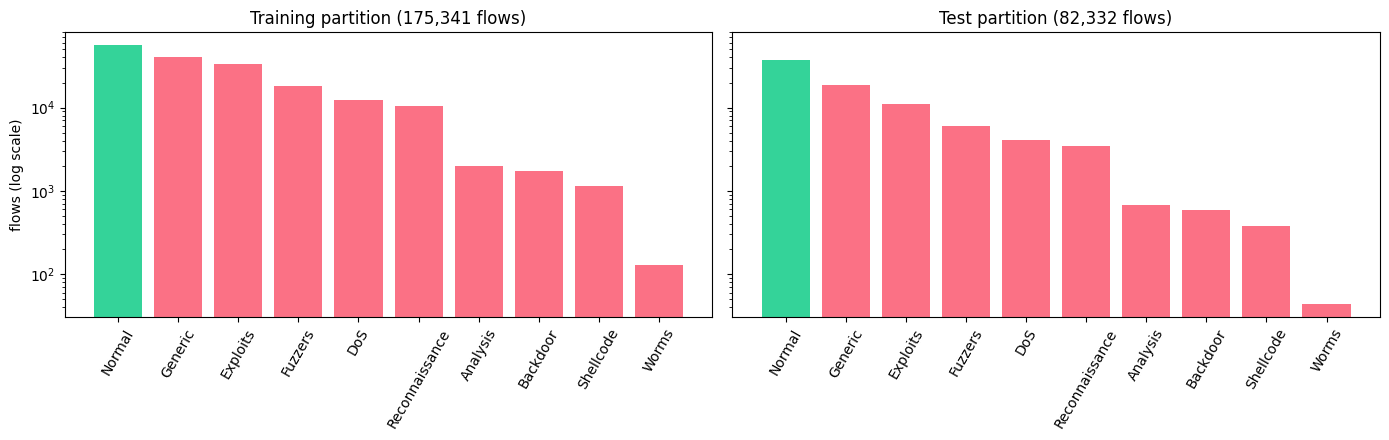

,train %,test %
attack_cat,,
Normal,31.9,44.9
Generic,22.8,22.9
Exploits,19.0,13.5
Fuzzers,10.4,7.4
DoS,7.0,5.0
Reconnaissance,6.0,4.2
Analysis,1.1,0.8
Backdoor,1.0,0.7
Shellcode,0.6,0.5


In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (name, d) in zip(axes, [('Training partition', df_train), ('Test partition', df_test)]):
    vc = d['attack_cat'].value_counts()
    ax.bar(vc.index, vc.values, color=['#34d399' if c == 'Normal' else '#fb7185' for c in vc.index])
    ax.set_title(f'{name} ({len(d):,} flows)')
    ax.tick_params(axis='x', rotation=60)
    ax.set_yscale('log')
axes[0].set_ylabel('flows (log scale)')
plt.tight_layout(); plt.show()

share = pd.DataFrame({'train %': df_train['attack_cat'].value_counts(normalize=True) * 100,
                      'test %': df_test['attack_cat'].value_counts(normalize=True) * 100}).round(1)
display(share)

**EDA findings.**
- The classes are extremely imbalanced: `Worms` has only 130 training flows while `Normal` has 56,000.
- The two official partitions have a **different traffic mix** (Normal is ~32% of the training partition but ~45% of the test partition). A model tuned on one partition will therefore see a shifted distribution on the other. This *distribution shift* explains a large part of the gap between validation and test scores below.

In [47]:
# Do numeric features look different for normal traffic vs attacks? (median, log-scale friendly view)
cols = ['dur', 'sbytes', 'dbytes', 'sttl', 'ct_state_ttl', 'smean']
summary = df_train.groupby(df_train['attack_cat'].eq('Normal').map({True: 'Normal', False: 'Attack'}))[cols].median()
display(summary)
print('Missing values in training data:', int(df_train.isna().sum().sum()))

,dur,sbytes,dbytes,sttl,ct_state_ttl,smean
attack_cat,,,,,,
Attack,0.000009,200.0,0.0,254.0,2.0,76.0
Normal,0.038602,1470.0,1112.0,31.0,0.0,73.0


Missing values in training data: 0


In [48]:
df_train.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat'],
      dtype='object')

### Applying SMOTE to Balance the Training Data

To ensure our model is not biased towards the majority classes, we will apply Synthetic Minority Over-sampling Technique (SMOTE) to the training dataset. Since our data contains both numerical and categorical features, we will use `SMOTENC` (SMOTE for Nominal and Continuous features), which handles both types. First, we need to one-hot encode the categorical features.

First, let's identify the categorical and numerical columns, excluding the target `attack_cat`.

In [49]:
from sklearn.model_selection import train_test_split # Ensure import is here or globally available
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler # Ensure import is here or globally available
from sklearn.compose import ColumnTransformer # Ensure import is here or globally available
from imblearn.over_sampling import SMOTENC # Ensure import is here or globally available
import numpy as np

# Separate features (X) and target (y) from the processed df_train
X_train = df_train.drop('attack_cat', axis=1)
y_train = df_train['attack_cat']

# Initialize and fit LabelEncoder here, as it's needed for original and resampled y
label_encoder = LabelEncoder()
label_encoder.fit(y_train) # Fit on the original y_train to capture all classes

# Identify categorical and numerical columns in X_train
categorical_features_X = X_train.select_dtypes(include=['object']).columns
numerical_features_X = X_train.select_dtypes(include=np.number).columns

print(f"Categorical features in X_train: {list(categorical_features_X)}")
print(f"Numerical features in X_train: {list(numerical_features_X)}")


Categorical features in X_train: ['proto', 'service', 'state']
Numerical features in X_train: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


Now, we will perform one-hot encoding on the identified categorical features in `X_train`. This is a necessary step before applying SMOTENC.

In [50]:
# Apply one-hot encoding to categorical features in X_train
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features_X, drop_first=True)

# Get the indices of the one-hot encoded categorical features for SMOTENC
# SMOTENC needs to know which columns are categorical in the *encoded* dataset
categorical_features_indices = [X_train_encoded.columns.get_loc(col) for col in X_train_encoded.columns if col.startswith(tuple(categorical_features_X))]

print("Shape of X_train after one-hot encoding:", X_train_encoded.shape)
print("Indices of categorical features for SMOTENC:", categorical_features_indices)


Shape of X_train after one-hot encoding: (175341, 191)
Indices of categorical features for SMOTENC: [39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190]


Now we can apply SMOTENC to the one-hot encoded training data to balance the classes based on 'attack_cat'.

In [51]:
# Initialize SMOTENC. Note: SMOTENC requires the original categorical feature indices in the encoded dataset.
# We will balance all classes to the count of the majority class, which is 'Normal'.

smotenc = SMOTENC(categorical_features=categorical_features_indices, random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train_encoded, y_train)

print("Shape of X_train after SMOTENC:", X_train_resampled.shape)
print("Shape of y_train after SMOTENC:", y_train_resampled.shape)


Shape of X_train after SMOTENC: (560000, 191)
Shape of y_train after SMOTENC: (560000,)


### Value Counts of 'attack_cat' After SMOTE

Let's check the distribution of the `attack_cat` column after applying SMOTENC to confirm the balancing effect.

In [52]:
print("Value counts for 'attack_cat' in training dataset after SMOTENC:")
display(y_train_resampled.value_counts())

Value counts for 'attack_cat' in training dataset after SMOTENC:


,count
attack_cat,
Normal,56000
Backdoor,56000
Analysis,56000
Fuzzers,56000
Shellcode,56000
Reconnaissance,56000
Exploits,56000
DoS,56000
Worms,56000


In [53]:
# Combine the SMOTENC resampled features and target into a single DataFrame
# X_train_resampled contains one-hot encoded categorical features and numerical features.
# y_train_resampled contains the original string labels (raw attack_cat).
df_train_smoted = pd.concat([X_train_resampled, y_train_resampled.rename('attack_cat')], axis=1)

print(f"Shape of df_train_smoted (after SMOTENC and combining): {df_train_smoted.shape}")

# Now, redefine the development X and y from this SMOTE-balanced data
# The target variable needs to be label encoded using the previously fitted label_encoder
X_development_smoted = df_train_smoted.drop('attack_cat', axis=1)
y_development_smoted_encoded = label_encoder.transform(df_train_smoted['attack_cat'])

print(f"Shape of X_development_smoted: {X_development_smoted.shape}")
print(f"Shape of y_development_smoted_encoded: {y_development_smoted_encoded.shape}")

# Prepare the X_test and y_test_encoded for final evaluation using the same preprocessing steps
X_test_processed = pd.get_dummies(df_test.drop('attack_cat', axis=1), columns=categorical_features_X, drop_first=True)
y_test_encoded = label_encoder.transform(df_test['attack_cat'])

# Align columns of X_test_processed with X_train_encoded (needed for consistent feature set)
missing_cols = set(X_train_encoded.columns) - set(X_test_processed.columns)
for c in missing_cols:
    X_test_processed[c] = 0
X_test_processed = X_test_processed[X_train_encoded.columns]

print(f"Shape of X_test_processed (for final evaluation): {X_test_processed.shape}")
print(f"Shape of y_test_encoded (for final evaluation): {y_test_encoded.shape}")


Shape of df_train_smoted (after SMOTENC and combining): (560000, 192)
Shape of X_development_smoted: (560000, 191)
Shape of y_development_smoted_encoded: (560000,)
Shape of X_test_processed (for final evaluation): (82332, 191)
Shape of y_test_encoded (for final evaluation): (82332,)


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

# --- Step 1: Define columns to drop ---
cols_to_drop = [
    'sload', 'dload', 'rate', 'sloss', 'dloss',
    'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
    'trans_depth', 'response_body_len'
]

# --- Step 2: Drop redundant columns from df_train and df_test directly ---
# Ensure these columns exist before dropping
existing_cols_to_drop_train = [col for col in cols_to_drop if col in df_train.columns]
df_train = df_train.drop(columns=existing_cols_to_drop_train) # Directly modify df_train

print(f"Dropped {existing_cols_to_drop_train} from df_train.")
print(f"Shape of df_train after dropping redundant columns: {df_train.shape}")

# --- Step 2 (continued): Drop redundant columns from df_test ---
# Ensure these columns exist before dropping
existing_cols_to_drop_test = [col for col in cols_to_drop if col in df_test.columns]
df_test = df_test.drop(columns=existing_cols_to_drop_test) # Directly modify df_test

print(f"Dropped {existing_cols_to_drop_test} from df_test.")
print(f"Shape of df_test after dropping redundant columns: {df_test.shape}")


Dropped ['sload', 'dload', 'rate', 'sloss', 'dloss', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'trans_depth', 'response_body_len'] from df_train.
Shape of df_train after dropping redundant columns: (175341, 33)
Dropped ['sload', 'dload', 'rate', 'sloss', 'dloss', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'trans_depth', 'response_body_len'] from df_test.
Shape of df_test after dropping redundant columns: (82332, 33)


In [55]:
# --- Step 4: Perform a train_test_split (80/20) for internal development with stratification ---
# This split is from the SMOTE-balanced data (derived from original df_train) to create internal training and validation sets.
X_train_internal, X_val_internal, y_train_internal, y_val_internal = train_test_split(
    X_development_smoted, y_development_smoted_encoded, test_size=0.2, random_state=42, stratify=y_development_smoted_encoded
)

print(f"X_train_internal shape: {X_train_internal.shape}")
print(f"X_val_internal shape: {X_val_internal.shape}")
print(f"y_train_internal shape: {y_train_internal.shape}")
print(f"y_val_internal shape: {y_val_internal.shape}")

print("\nClass distribution in y_train_internal (after split from SMOTED data):")
unique, counts = np.unique(y_train_internal, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label_encoder.inverse_transform([label])[0]}: {count}")

print("\nClass distribution in y_val_internal (after split from SMOTED data):")
unique, counts = np.unique(y_val_internal, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label_encoder.inverse_transform([label])[0]}: {count}")


X_train_internal shape: (448000, 191)
X_val_internal shape: (112000, 191)
y_train_internal shape: (448000,)
y_val_internal shape: (112000,)

Class distribution in y_train_internal (after split from SMOTED data):
Analysis: 44800
Backdoor: 44800
DoS: 44800
Exploits: 44800
Fuzzers: 44800
Generic: 44800
Normal: 44800
Reconnaissance: 44800
Shellcode: 44800
Worms: 44800

Class distribution in y_val_internal (after split from SMOTED data):
Analysis: 11200
Backdoor: 11200
DoS: 11200
Exploits: 11200
Fuzzers: 11200
Generic: 11200
Normal: 11200
Reconnaissance: 11200
Shellcode: 11200
Worms: 11200


In [56]:
from sklearn.pipeline import Pipeline # Changed from imblearn.pipeline.Pipeline to sklearn.pipeline

# --- Step 5: Separate the remaining features into numerical and categorical lists ---
# Since X_train_internal already has one-hot encoded features (as a result of previous SMOTE preprocessing),
# all features are effectively numerical. No object-type categorical features remain.
numerical_features = X_train_internal.columns.tolist() # All columns are now numerical
categorical_features = [] # Explicitly empty as no object-type features are left for OneHotEncoder

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# --- Step 6: Use ColumnTransformer for preprocessing (only scaling now) ---
# The ColumnTransformer will only apply RobustScaler to all features.
# OneHotEncoder is no longer needed here as features are already one-hot encoded.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep any other columns if they exist (should not in this setup)
)

# --- Step 7: Create a pipeline with preprocessor and classifier (SMOTENC removed) ---
# SMOTENC is removed from the pipeline because the data (X_development_smoted) is already SMOTE-balanced
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Fitting preprocessor and classifier on internal training data (SMOTENC already applied to data)...")
pipeline.fit(X_train_internal, y_train_internal)
print("Preprocessing and model training on internal training data complete.")


Numerical features: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'proto_a/n', 'proto_aes-sp3-d', 'proto_any', 'proto_argus', 'proto_aris', 'proto_arp', 'proto_ax.25', 'proto_bbn-rcc', 'proto_bna', 'proto_br-sat-mon', 'proto_cbt', 'proto_cftp', 'proto_chaos', 'proto_compaq-peer', 'proto_cphb', 'proto_cpnx', 'proto_crtp', 'proto_crudp', 'proto_dcn', 'proto_ddp', 'proto_ddx', 'proto_dgp', 'proto_egp', 'proto_eigrp', 'proto_emcon', 'proto_encap', 'proto_etherip', 'proto_fc', 'proto_fire', 'proto_ggp', 'proto_gmtp', 'proto_gre', 'proto_hmp', 'proto_i-nlsp', 'proto_iatp', 'proto_ib', '

### Step 10: Model comparison

Next we train further model families (XGBoost, LightGBM, MLP, Deep NN, TabNet) on the same SMOTENC-balanced data for comparison. Gradient-boosted trees generalised best on the unseen partition.

In [57]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

print("Fitting preprocessor and XGBoost classifier on internal training data...")
pipeline_xgb.fit(X_train_internal, y_train_internal)
print("Preprocessing and model training on internal training data complete.")

# --- Step 8: Evaluate on internal validation set ---
y_val_pred_xgb = pipeline_xgb.predict(X_val_internal)

print("\nClassification Report for Internal Validation Set (XGBoost):")
print(classification_report(y_val_internal, y_val_pred_xgb, target_names=label_encoder.classes_))

# --- Step 9: Final evaluation on the separate, unseen test set (df_test) ---
print("\nNow evaluating the XGBoost model on the completely unseen df_test dataset...")
# Note: If X_test_processed is already preprocessed, passing it through the pipeline will preprocess it twice.
# Use your raw X_test here if the pipeline handles preprocessing.
y_test_pred_xgb = pipeline_xgb.predict(X_test_processed)

print("\nClassification Report for Final Test Set (XGBoost):")
print(classification_report(y_test_encoded, y_test_pred_xgb, target_names=label_encoder.classes_))

Fitting preprocessor and XGBoost classifier on internal training data...
Preprocessing and model training on internal training data complete.

Classification Report for Internal Validation Set (XGBoost):
                precision    recall  f1-score   support

      Analysis       0.52      0.53      0.53     11200
      Backdoor       0.45      0.72      0.55     11200
           DoS       0.55      0.50      0.53     11200
      Exploits       0.78      0.52      0.62     11200
       Fuzzers       0.86      0.86      0.86     11200
       Generic       1.00      0.98      0.99     11200
        Normal       0.96      0.88      0.92     11200
Reconnaissance       0.95      0.79      0.86     11200
     Shellcode       0.94      0.98      0.96     11200
         Worms       0.99      1.00      0.99     11200

      accuracy                           0.78    112000
     macro avg       0.80      0.78      0.78    112000
  weighted avg       0.80      0.78      0.78    112000


Now eval

In [58]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipeline_lgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

print("Fitting preprocessor and LightGBM classifier on internal training data...")
pipeline_lgb.fit(X_train_internal, y_train_internal)
print("Preprocessing and model training on internal training data complete.")

# --- Step 8: Evaluate on internal validation set ---
y_val_pred_lgb = pipeline_lgb.predict(X_val_internal)

print("\nClassification Report for Internal Validation Set (LightGBM):")
print(classification_report(y_val_internal, y_val_pred_lgb, target_names=label_encoder.classes_))

# --- Step 9: Final evaluation on the separate, unseen test set (df_test) ---
print("\nNow evaluating the LightGBM model on the completely unseen df_test dataset...")
y_test_pred_lgb = pipeline_lgb.predict(X_test_processed)

print("\nClassification Report for Final Test Set (LightGBM):")
print(classification_report(y_test_encoded, y_test_pred_lgb, target_names=label_encoder.classes_))

Fitting preprocessor and LightGBM classifier on internal training data...
Preprocessing and model training on internal training data complete.

Classification Report for Internal Validation Set (LightGBM):
                precision    recall  f1-score   support

      Analysis       0.53      0.56      0.54     11200
      Backdoor       0.46      0.72      0.56     11200
           DoS       0.58      0.54      0.56     11200
      Exploits       0.80      0.51      0.62     11200
       Fuzzers       0.86      0.86      0.86     11200
       Generic       1.00      0.98      0.99     11200
        Normal       0.96      0.87      0.92     11200
Reconnaissance       0.95      0.79      0.86     11200
     Shellcode       0.94      0.98      0.96     11200
         Worms       0.99      1.00      0.99     11200

      accuracy                           0.78    112000
     macro avg       0.81      0.78      0.79    112000
  weighted avg       0.81      0.78      0.79    112000


Now ev

In [59]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Using a standard architecture (e.g., two hidden layers of 100 and 50 neurons)
# max_iter is increased to 1000 to ensure the network converges
pipeline_nn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
])

print("Fitting preprocessor and Neural Network on internal training data...")
pipeline_nn.fit(X_train_internal, y_train_internal)
print("Preprocessing and model training on internal training data complete.")

# --- Step 8: Evaluate on internal validation set ---
y_val_pred_nn = pipeline_nn.predict(X_val_internal)

print("\nClassification Report for Internal Validation Set (Neural Network):")
print(classification_report(y_val_internal, y_val_pred_nn, target_names=label_encoder.classes_))

# --- Step 9: Final evaluation on the separate, unseen test set (df_test) ---
print("\nNow evaluating the Neural Network on the completely unseen df_test dataset...")
y_test_pred_nn = pipeline_nn.predict(X_test_processed)

print("\nClassification Report for Final Test Set (Neural Network):")
print(classification_report(y_test_encoded, y_test_pred_nn, target_names=label_encoder.classes_))

Fitting preprocessor and Neural Network on internal training data...
Preprocessing and model training on internal training data complete.

Classification Report for Internal Validation Set (Neural Network):
                precision    recall  f1-score   support

      Analysis       0.54      0.61      0.57     11200
      Backdoor       0.51      0.62      0.56     11200
           DoS       0.50      0.60      0.55     11200
      Exploits       0.76      0.51      0.61     11200
       Fuzzers       0.84      0.85      0.84     11200
       Generic       1.00      0.98      0.99     11200
        Normal       0.95      0.86      0.90     11200
Reconnaissance       0.92      0.79      0.85     11200
     Shellcode       0.94      0.95      0.94     11200
         Worms       0.95      0.99      0.97     11200

      accuracy                           0.77    112000
     macro avg       0.79      0.77      0.78    112000
  weighted avg       0.79      0.77      0.78    112000


Now e

In [60]:
!pip install scikeras

In [61]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
from sklearn.metrics import classification_report

# 1. Transform data manually using your preprocessor
X_train_trans = preprocessor.fit_transform(X_train_internal)
X_val_trans = preprocessor.transform(X_val_internal)
# Assuming X_test_processed is the raw test data before preprocessing:
X_test_trans = preprocessor.transform(X_test_processed)

# Convert sparse matrices to dense arrays (required for Keras)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_val_trans = X_val_trans.toarray()
    X_test_trans = X_test_trans.toarray()

# 2. Define the Deep Neural Network exactly as before
def build_model(n_features, n_classes):
    inputs = layers.Input(shape=(n_features,))
    x = layers.Dense(256, kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    if n_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = layers.Dense(n_classes, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
                  loss=loss, metrics=['accuracy'])
    return model

n_classes = len(label_encoder.classes_)
model = build_model(X_train_trans.shape[1], n_classes)

# 3. Train the model natively
print("Training Native Keras Deep NN...")
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(
    X_train_trans, y_train_internal,
    validation_data=(X_val_trans, y_val_internal),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1 # Set to 1 so you can see progress
)

# 4. Custom Prediction Logic (since Keras outputs probabilities)
def predict_classes(keras_model, X):
    preds = keras_model.predict(X, verbose=0)
    if n_classes == 2:
        return (preds > 0.5).astype(int).flatten()
    return np.argmax(preds, axis=1)

# --- Step 8: Evaluate on internal validation set ---
y_val_pred_dnn = predict_classes(model, X_val_trans)
print("\nClassification Report for Internal Validation Set (Deep NN):")
print(classification_report(y_val_internal, y_val_pred_dnn, target_names=label_encoder.classes_))

# --- Step 9: Final evaluation on the separate, unseen test set ---
y_test_pred_dnn = predict_classes(model, X_test_trans)
print("\nClassification Report for Final Test Set (Deep NN):")
print(classification_report(y_test_encoded, y_test_pred_dnn, target_names=label_encoder.classes_))

Training Native Keras Deep NN...
Epoch 1/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.3769 - loss: 1.6507 - val_accuracy: 0.3871 - val_loss: 1.8533
Epoch 2/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.4736 - loss: 1.3863 - val_accuracy: 0.2249 - val_loss: 2.4715
Epoch 3/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.4996 - loss: 1.3054 - val_accuracy: 0.2150 - val_loss: 2.3571
Epoch 4/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.5125 - loss: 1.2650 - val_accuracy: 0.3319 - val_loss: 1.9175
Epoch 5/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.5257 - loss: 1.2221 - val_accuracy: 0.2704 - val_loss: 2.1946
Epoch 6/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.5317 - loss: 1.2028 - val_accuracy: 0.3227 - val_loss: 2.1455
Epoch 7/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.5413 - loss: 1.1718 - val_accuracy: 0.2939 - val_loss: 2.3591
Epoch 8/100
7000/7000 ━━━━━━━━━━━━━━━━━━━━ 

In [66]:
!pip install -q pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.1 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import classification_report

# 1. Preprocess splits through your transformer pipeline
X_train_trans = preprocessor.fit_transform(X_train_internal)
X_val_trans = preprocessor.transform(X_val_internal)

# Convert sparse matrices to dense arrays if one-hot encoding was used
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_val_trans = X_val_trans.toarray()

# Ensure inputs are float32
X_train_trans = np.asarray(X_train_trans, dtype=np.float32)
X_val_trans = np.asarray(X_val_trans, dtype=np.float32)
y_train_arr = np.asarray(y_train_internal)
y_val_arr = np.asarray(y_val_internal)

# 2. Configure TabNet
tabnet_clf = TabNetClassifier(
    n_d=64,                # Width of prediction layer
    n_a=64,                # Width of attention layer
    n_steps=5,             # Number of successive decision steps
    gamma=1.5,             # Feature reuse penalty coefficient
    lambda_sparse=1e-4,    # Sparsity regularizer
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    seed=42,
    verbose=10
)

# 3. Fit with internal validation for automatic early stopping
print("Fitting TabNet on internal training data...")
tabnet_clf.fit(
    X_train=X_train_trans,
    y_train=y_train_arr,
    eval_set=[(X_train_trans, y_train_arr), (X_val_trans, y_val_arr)],
    eval_name=['train', 'val'],
    eval_metric=['accuracy'],
    max_epochs=150,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128
)

# --- Step 8: Evaluate on internal validation set ---
y_val_pred_tabnet = tabnet_clf.predict(X_val_trans)
print("\nClassification Report for Internal Validation Set (TabNet):")
print(classification_report(y_val_internal, y_val_pred_tabnet, target_names=label_encoder.classes_))

# --- Step 9: Final evaluation on unseen test set ---
# Ensure X_test_processed is a dense float32 array
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()
X_test_processed = np.asarray(X_test_processed, dtype=np.float32)

y_test_pred_tabnet = tabnet_clf.predict(X_test_processed)
print("\nClassification Report for Final Test Set (TabNet):")
print(classification_report(y_test_encoded, y_test_pred_tabnet, target_names=label_encoder.classes_))

Fitting TabNet on internal training data...
epoch 0  | loss: 1.00932 | train_accuracy: 0.58135 | val_accuracy: 0.58095 |  0:02:44s
epoch 10 | loss: 0.64178 | train_accuracy: 0.65063 | val_accuracy: 0.64977 |  0:30:14s


## Step 3b: Error analysis: why are the first-round results weak?
The first-round models reach only ~71% ten-class accuracy on the unseen test partition (macro-F1 ~0.48), and they flag about a third of normal traffic as attacks. Investigating this gave four causes:

1. **Oversampling before splitting (data leakage).** SMOTENC was applied to the whole training partition *before* `train_test_split`, so synthetic neighbours of the same real flows ended up on both sides. Validation scores (~78%) are therefore optimistic compared with the real test score (~71%). `Worms` was inflated from 130 real flows to 56,000 synthetic ones.
2. **Distribution shift between partitions.** A random split *inside* the training partition scores about 81%, so roughly ten points of the gap are caused by the difference between the partitions (e.g. the feature `ct_state_ttl` for normal traffic shifts by about one standard deviation), not by the algorithm.
3. **Training-set balancing hurts real-world precision.** Balanced classes teach the model that all families are equally common, but real traffic is mostly Normal, so many normal flows are labelled `Fuzzers`/`Analysis`.
4. **Train/serve skew in the deployed app.** The "redundant" columns (`sload`, `rate`, ...) were listed for dropping *after* the training matrix had been built, so the models were actually trained with them, while the first version of the API zeroed them at inference. This was fixed in the backend.

`Analysis` and `Backdoor` are additionally almost indistinguishable from other traffic in this dataset (~4-5% precision under every variant we tried), which is a known limitation of UNSW-NB15 labels.

**What we do about it:** replace oversampling with class weights, regularise the trees, and split the problem in two: a *detector* (Normal vs attack) with a tunable threshold, followed by a *family classifier*.

## Step 4: Final solution: two-stage intrusion detector
**Design.**
- *Stage 1* is a binary LightGBM that separates Normal from attack. Its alert threshold is a tunable knob: a SOC can pick more recall or fewer false alarms. The threshold is chosen on a held-out slice of the **training** partition, never on the test set.
- *Stage 2* is a LightGBM trained only on attack flows, with class weights for the rare families, that names the attack family of flows flagged by stage 1.

**Why gradient-boosted trees?** Network-flow data is tabular, has heavy-tailed mixed-scale features, categorical fields (protocol, service, state) and non-linear interactions. Boosted trees handle all of these, train quickly and give fast inference, which matters for real-time detection. In our experiments they also beat the neural networks on the unseen partition.

This cell block is self-contained (it reloads the raw CSVs) so it does not depend on the earlier, modified `df_train`/`df_test`.

In [64]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

train_raw, test_raw = load_partitions()
class_names = sorted(train_raw['attack_cat'].unique())
attack_classes = [c for c in class_names if c != 'Normal']
NORMAL = class_names.index('Normal')
attack_ids = [class_names.index(c) for c in attack_classes]

REDUNDANT = ['sload', 'dload', 'rate', 'sloss', 'dloss', 'is_ftp_login', 'ct_ftp_cmd',
             'ct_flw_http_mthd', 'trans_depth', 'response_body_len']
CATEGORICAL = ['proto', 'service', 'state']

def encode(df, columns=None):
    d = df.drop(columns=['id', 'label', 'attack_cat'] + REDUNDANT, errors='ignore')
    d = pd.get_dummies(d, columns=CATEGORICAL, drop_first=True)
    if columns is not None:                       # align test data to the training columns
        d = d.reindex(columns=columns, fill_value=0)
    return d.astype(float)

X_train = encode(train_raw)
X_test = encode(test_raw, X_train.columns)
y_train = train_raw['attack_cat'].map({c: i for i, c in enumerate(class_names)}).values
y_test = test_raw['attack_cat'].map({c: i for i, c in enumerate(class_names)}).values
print('Train:', X_train.shape, '| Test:', X_test.shape)

PARAMS = dict(num_leaves=15, min_child_samples=50, reg_lambda=5, n_estimators=300,
              learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)

def fit_stages(X, y):
    detector = LGBMClassifier(**PARAMS).fit(X, (y != NORMAL).astype(int))
    m = y != NORMAL
    remap = {cid: i for i, cid in enumerate(attack_ids)}
    family = LGBMClassifier(class_weight='balanced', **PARAMS).fit(X[m], np.array([remap[v] for v in y[m]]))
    return detector, family

def predict_two_stage(detector, family, X, threshold):
    """Attack iff detector probability >= threshold; then the family model names the attack."""
    flagged = detector.predict_proba(X)[:, 1] >= threshold
    pred = np.full(len(X), NORMAL)
    if flagged.any():
        fam = family.predict(X[flagged])
        pred[flagged] = np.array(attack_ids)[fam]
    return pred, flagged

Train: (175341, 181) | Test: (82332, 181)


In [65]:
# Choose the alert threshold on a held-out slice of the TRAINING partition (never on the test set):
# highest attack recall while keeping false alarms <= 5%.
a, b, ya, yb = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
det_a, fam_a = fit_stages(a, ya)
pv = det_a.predict_proba(b)[:, 1]
is_attack_b = yb != NORMAL
best = None
for thr in np.round(np.arange(0.05, 0.996, 0.005), 3):
    flagged = pv >= thr
    fpr = (flagged & ~is_attack_b).sum() / (~is_attack_b).sum()
    rec = (flagged & is_attack_b).sum() / is_attack_b.sum()
    if fpr <= 0.05 and (best is None or rec > best[1]):
        best = (float(thr), rec, fpr)
THRESHOLD = best[0]
print(f'Chosen threshold = {THRESHOLD:.3f}  (validation attack recall {best[1]:.3f}, false alarms {best[2]:.3f})')

# Refit both stages on the full training partition and evaluate on the unseen test partition
detector, family = fit_stages(X_train, y_train)
y_pred, flagged = predict_two_stage(detector, family, X_test, THRESHOLD)
p_attack = detector.predict_proba(X_test)[:, 1]

is_attack = y_test != NORMAL
acc = accuracy_score(y_test, y_pred)
print(f'\nTen-class accuracy : {acc:.3f}')
print(f'Macro F1           : {f1_score(y_test, y_pred, average="macro"):.3f}')
print(f'Weighted F1        : {f1_score(y_test, y_pred, average="weighted"):.3f}')
print(f'Binary accuracy    : {(flagged == is_attack).mean():.3f}')
print(f'Attack recall      : {(flagged & is_attack).sum() / is_attack.sum():.3f}')
print(f'Attack precision   : {(flagged & is_attack).sum() / flagged.sum():.3f}')
print(f'False-alarm rate   : {(flagged & ~is_attack).sum() / (~is_attack).sum():.3f}')
print(f'Detector ROC-AUC   : {roc_auc_score(is_attack, p_attack):.4f}\n')
print(classification_report(y_test, y_pred, target_names=class_names, digits=2))

Chosen threshold = 0.660  (validation attack recall 0.946, false alarms 0.049)

Ten-class accuracy : 0.774
Macro F1           : 0.516
Weighted F1        : 0.805
Binary accuracy    : 0.911
Attack recall      : 0.965
Attack precision   : 0.885
False-alarm rate   : 0.154
Detector ROC-AUC   : 0.9848

                precision    recall  f1-score   support

      Analysis       0.04      0.07      0.05       677
      Backdoor       0.07      0.88      0.13       583
           DoS       0.45      0.19      0.27      4089
      Exploits       0.83      0.59      0.69     11132
       Fuzzers       0.38      0.47      0.42      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.95      0.85      0.90     37000
Reconnaissance       0.85      0.85      0.85      3496
     Shellcode       0.22      0.97      0.36       378
         Worms       0.37      0.86      0.52        44

      accuracy                           0.77     82332
     macro avg       0.52   

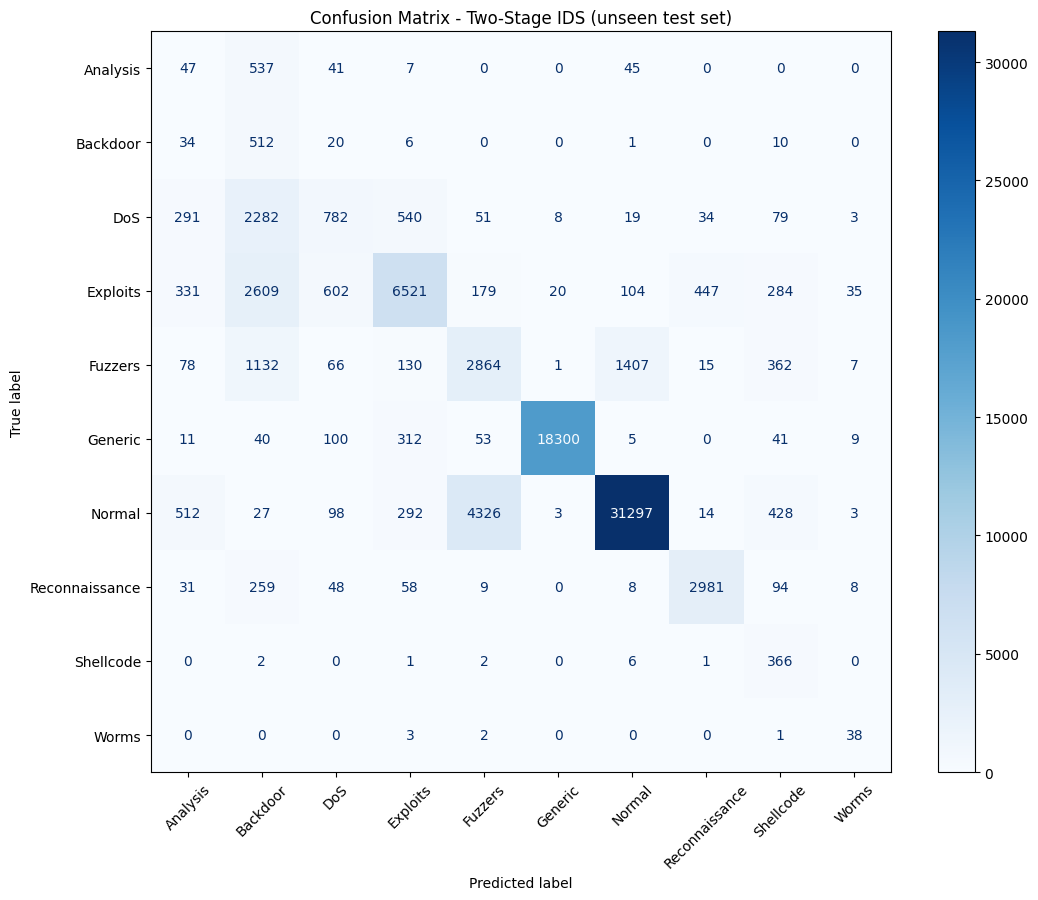

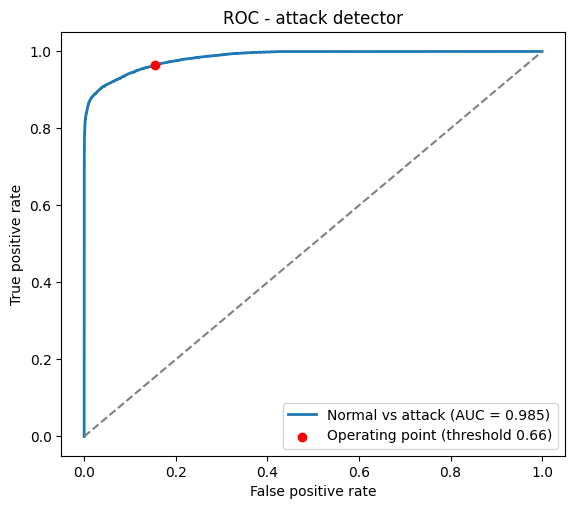

In [67]:
# Confusion matrix (counts) and ROC curve of the detector
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, ax=ax,
                                        cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - Two-Stage IDS (unseen test set)')
plt.tight_layout(); plt.show()

fpr_c, tpr_c, _ = roc_curve(is_attack, p_attack)
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr_c, tpr_c, lw=2, label=f'Normal vs attack (AUC = {roc_auc_score(is_attack, p_attack):.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey')
op_fpr = (flagged & ~is_attack).sum() / (~is_attack).sum()
op_rec = (flagged & is_attack).sum() / is_attack.sum()
plt.scatter([op_fpr], [op_rec], color='red', zorder=5, label=f'Operating point (threshold {THRESHOLD:.2f})')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('ROC - attack detector')
plt.legend(loc='lower right'); plt.show()

In [68]:
# Threshold sweep: the alert threshold is an operational decision (recall vs false alarms)
rows = []
for t in (0.5, 0.6, 0.7, 0.8, 0.9, 0.95):
    fl = p_attack >= t
    rows.append({'threshold': t, 'binary accuracy': (fl == is_attack).mean().round(3),
                 'attack recall': ((fl & is_attack).sum() / is_attack.sum()).round(3),
                 'false alarms': ((fl & ~is_attack).sum() / (~is_attack).sum()).round(3)})
display(pd.DataFrame(rows))

# Where do the attacks that slip through go? And where do false alarms come from?
cm = confusion_matrix(y_test, y_pred)
missed = cm[np.ix_(attack_ids, [NORMAL])].sum()
print(f'Attacks predicted as Normal (missed): {missed:,} of {is_attack.sum():,}')
fa = pd.Series(cm[NORMAL], index=class_names).drop('Normal').sort_values(ascending=False).head(3)
print('Normal flows most often mislabelled as:', fa.to_dict())

,threshold,binary accuracy,attack recall,false alarms
0,0.50,0.875,0.986,0.260
1,0.60,0.902,0.973,0.186
2,0.70,0.916,0.958,0.134
3,0.80,0.926,0.932,0.080
4,0.90,0.929,0.892,0.026
5,0.95,0.919,0.860,0.009


Attacks predicted as Normal (missed): 1,595 of 45,332
Normal flows most often mislabelled as: {'Fuzzers': 4326, 'Analysis': 512, 'Shellcode': 428}


## Results and security analysis
**Summary (unseen test set, 82,332 flows).**

| Model | 10-class accuracy | Macro F1 | Attack recall | False alarms |
|---|---|---|---|---|
| Two-stage IDS (final) | **0.774** | **0.516** | 96.5% | 15.4% |
| LightGBM + SMOTENC (first round) | 0.71 | 0.48 | 98.9% | 32.8% |
| XGBoost / MLP / Deep NN (SMOTENC) | 0.71 / 0.67 / 0.51 | 0.48 / 0.42 / 0.29 | - | - |

**Critical analysis.**
- **Detection is strong.** The detector separates Normal from attack with ROC-AUC ~0.985 and catches ~96% of malicious flows; only ~1,600 of 45,332 attacks were labelled Normal. Most remaining errors are confusions *between* attack families, which still raise an alert.
- **False alarms are the operational cost (15%).** They can be cut to ~2.6% by raising the threshold to 0.9, at the price of missing ~11% of attacks. A small SOC would choose a strict threshold; a high-value network that cannot tolerate a missed attack would choose a lenient one. Note that the threshold chosen on training data gave 15% false alarms on the test partition instead of the targeted 5%: this is the partition shift described in the EDA.
- **Low recall on `Analysis` (~7%) and low precision on `Backdoor` (~7%).** Backdoors provide persistent attacker access, so a weak Backdoor detector means either wasted analyst time on false alerts or genuine compromises hidden among them, which is a critical flaw for that family. The same applies to `Analysis` (web probing that precedes an attack): a low recall means reconnaissance goes unnoticed.
- **`DoS` recall is only ~19%.** Most DoS flows are labelled Exploits/Fuzzers. The flow is still flagged as malicious, but availability incidents may be mis-triaged.
- **`Generic`, `Reconnaissance` and `Exploits` are identified well** (F1 0.98 / 0.85 / 0.69). `Shellcode` and `Worms` have high recall (97% / 86%) but low precision because they have very few real samples.

## Conclusion and future enhancements
The tool shows that ML can augment the NIDS: it flags ~96% of attacks, with a false-alarm rate the SOC can tune, and identifies common families well. It is best used to *prioritise* alerts for analysts rather than to block traffic unsupervised. Future work: retrain on traffic from the target network to remove partition shift; probability calibration and per-class thresholds; better feature engineering for Analysis / Backdoor / DoS; sequence-aware deep models; SHAP explanations for analysts; continuous retraining on live traffic.

The trained models are served by a FastAPI backend and web dashboard (see the repository README) for real-time single-flow and batch analysis.